In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 

In [2]:
import platform

from matplotlib import font_manager, rc
plt.rcParams['axes.unicode_minus'] = False

if platform.system() == 'Darwin':
    rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    path = "c:/Windows/Fonts/malgun.ttf"
    font_name = font_manager.FontProperties(fname=path).get_name()
    rc('font', family=font_name)
else:
    print('Unknown system... sorry~~~~')

# 1. 데이터 불러오기

In [31]:
# 상반기 주유소 판매 데이터 불러오기
first = pd.read_csv('../data/2019년 상반기 주유소 판매가격.csv', encoding="cp949")
first

,번호,지역,상호,주소,기간,상표,셀프여부,고급휘발유,휘발유,경유,실내등유
0,A0006039,서울 강남구,(주)동하힐탑셀프주유소,서울 강남구 논현로 640,20190101,SK에너지,셀프,1673,1465,1365,0
1,A0006039,서울 강남구,(주)동하힐탑셀프주유소,서울 강남구 논현로 640,20190102,SK에너지,셀프,1673,1465,1365,0
2,A0006039,서울 강남구,(주)동하힐탑셀프주유소,서울 강남구 논현로 640,20190103,SK에너지,셀프,1673,1465,1365,0
3,A0006039,서울 강남구,(주)동하힐탑셀프주유소,서울 강남구 논현로 640,20190104,SK에너지,셀프,1673,1465,1365,0
4,A0006039,서울 강남구,(주)동하힐탑셀프주유소,서울 강남구 논현로 640,20190105,SK에너지,셀프,1673,1465,1365,0
...,...,...,...,...,...,...,...,...,...,...,...
90585,A0032659,서울 중랑구,지에스칼텍스㈜ 소망주유소,서울 중랑구 망우로 475,20190626,GS칼텍스,셀프,0,1529,1389,0
90586,A0032659,서울 중랑구,지에스칼텍스㈜ 소망주유소,서울 중랑구 망우로 475,20190627,GS칼텍스,셀프,0,1529,1389,0
90587,A0032659,서울 중랑구,지에스칼텍스㈜ 소망주유소,서울 중랑구 망우로 475,20190628,GS칼텍스,셀프,0,1529,1389,0
90588,A0032659,서울 중랑구,지에스칼텍스㈜ 소망주유소,서울 중랑구 망우로 475,20190629,GS칼텍스,셀프,0,1529,1389,0


In [32]:
second =  pd.read_csv('../data/2019년 하반기 주유소 판매가격.csv', encoding="cp949")
second

,번호,지역,상호,주소,기간,상표,셀프여부,고급휘발유,휘발유,경유,실내등유
0,A0006039,서울 강남구,(주)동하힐탑셀프주유소,서울 강남구 논현로 640,20190701,SK에너지,셀프,1777,1577,1477,0
1,A0006039,서울 강남구,(주)동하힐탑셀프주유소,서울 강남구 논현로 640,20190702,SK에너지,셀프,1777,1577,1477,0
2,A0006039,서울 강남구,(주)동하힐탑셀프주유소,서울 강남구 논현로 640,20190703,SK에너지,셀프,1777,1577,1477,0
3,A0006039,서울 강남구,(주)동하힐탑셀프주유소,서울 강남구 논현로 640,20190704,SK에너지,셀프,1777,1577,1477,0
4,A0006039,서울 강남구,(주)동하힐탑셀프주유소,서울 강남구 논현로 640,20190705,SK에너지,셀프,1777,1577,1477,0
...,...,...,...,...,...,...,...,...,...,...,...
91119,A0032659,서울 중랑구,지에스칼텍스㈜ 소망주유소,서울 중랑구 망우로 475,20191227,GS칼텍스,셀프,0,1540,1389,1100
91120,A0032659,서울 중랑구,지에스칼텍스㈜ 소망주유소,서울 중랑구 망우로 475,20191228,GS칼텍스,셀프,0,1540,1389,1100
91121,A0032659,서울 중랑구,지에스칼텍스㈜ 소망주유소,서울 중랑구 망우로 475,20191229,GS칼텍스,셀프,0,1540,1389,1100
91122,A0032659,서울 중랑구,지에스칼텍스㈜ 소망주유소,서울 중랑구 망우로 475,20191230,GS칼텍스,셀프,0,1540,1389,1100


In [33]:
# 상반기 판매가격 데이터 프레임 결측치 조회
first.isnull().sum()

번호       0
지역       0
상호       0
주소       0
기간       0
상표       0
셀프여부     0
고급휘발유    0
휘발유      0
경유       0
실내등유     0
dtype: int64

In [34]:
# 하반기 판매가격 데이터 프레임 결측치 조회
second.isnull().sum()

번호       0
지역       0
상호       0
주소       0
기간       0
상표       0
셀프여부     0
고급휘발유    0
휘발유      0
경유       0
실내등유     0
dtype: int64

# 2. 데이터 결합

In [35]:
# 상반기와 하반기 데이터를 상하로 결합
df = pd.concat([first, second])
df

,번호,지역,상호,주소,기간,상표,셀프여부,고급휘발유,휘발유,경유,실내등유
0,A0006039,서울 강남구,(주)동하힐탑셀프주유소,서울 강남구 논현로 640,20190101,SK에너지,셀프,1673,1465,1365,0
1,A0006039,서울 강남구,(주)동하힐탑셀프주유소,서울 강남구 논현로 640,20190102,SK에너지,셀프,1673,1465,1365,0
2,A0006039,서울 강남구,(주)동하힐탑셀프주유소,서울 강남구 논현로 640,20190103,SK에너지,셀프,1673,1465,1365,0
3,A0006039,서울 강남구,(주)동하힐탑셀프주유소,서울 강남구 논현로 640,20190104,SK에너지,셀프,1673,1465,1365,0
4,A0006039,서울 강남구,(주)동하힐탑셀프주유소,서울 강남구 논현로 640,20190105,SK에너지,셀프,1673,1465,1365,0
...,...,...,...,...,...,...,...,...,...,...,...
91119,A0032659,서울 중랑구,지에스칼텍스㈜ 소망주유소,서울 중랑구 망우로 475,20191227,GS칼텍스,셀프,0,1540,1389,1100
91120,A0032659,서울 중랑구,지에스칼텍스㈜ 소망주유소,서울 중랑구 망우로 475,20191228,GS칼텍스,셀프,0,1540,1389,1100
91121,A0032659,서울 중랑구,지에스칼텍스㈜ 소망주유소,서울 중랑구 망우로 475,20191229,GS칼텍스,셀프,0,1540,1389,1100
91122,A0032659,서울 중랑구,지에스칼텍스㈜ 소망주유소,서울 중랑구 망우로 475,20191230,GS칼텍스,셀프,0,1540,1389,1100


# 3. 데이터 가공 및 분석

In [36]:
# 데이터 프레임 정보 조회
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 181714 entries, 0 to 91123
Data columns (total 11 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   번호      181714 non-null  object
 1   지역      181714 non-null  object
 2   상호      181714 non-null  object
 3   주소      181714 non-null  object
 4   기간      181714 non-null  int64 
 5   상표      181714 non-null  object
 6   셀프여부    181714 non-null  object
 7   고급휘발유   181714 non-null  int64 
 8   휘발유     181714 non-null  int64 
 9   경유      181714 non-null  int64 
 10  실내등유    181714 non-null  int64 
dtypes: int64(5), object(6)
memory usage: 16.6+ MB


In [37]:
# 상표 컬럼의 고유값 조회
df['상표'].unique()

array(['SK에너지', 'GS칼텍스', 'S-OIL', '현대오일뱅크', '알뜰주유소', 'NH-OIL', '알뜰(ex)',
       '자가상표'], dtype=object)

In [38]:
# 지역 컬럼의 고유값 조회
df['지역'].unique()

array(['서울 강남구', '서울 강동구', '서울 강북구', '서울 강서구', '서울 관악구', '서울 광진구',
       '서울 구로구', '서울 금천구', '서울 노원구', '서울 도봉구', '서울 동대문구', '서울 동작구',
       '서울 마포구', '서울 서대문구', '서울 서초구', '서울 성동구', '서울 성북구', '서울 송파구',
       '서울 양천구', '서울 영등포구', '서울 용산구', '서울 은평구', '서울 종로구', '서울 중구',
       '서울 중랑구'], dtype=object)

In [39]:
# 지역 컬럼의 값을 이용하여 시와 구를 분리
df['시']=df['지역'].apply(lambda x : x.split(' ')[0])
df['구']=df['지역'].apply(lambda x : x.split(' ')[1])
df

,번호,지역,상호,주소,기간,상표,셀프여부,고급휘발유,휘발유,경유,실내등유,시,구
0,A0006039,서울 강남구,(주)동하힐탑셀프주유소,서울 강남구 논현로 640,20190101,SK에너지,셀프,1673,1465,1365,0,서울,강남구
1,A0006039,서울 강남구,(주)동하힐탑셀프주유소,서울 강남구 논현로 640,20190102,SK에너지,셀프,1673,1465,1365,0,서울,강남구
2,A0006039,서울 강남구,(주)동하힐탑셀프주유소,서울 강남구 논현로 640,20190103,SK에너지,셀프,1673,1465,1365,0,서울,강남구
3,A0006039,서울 강남구,(주)동하힐탑셀프주유소,서울 강남구 논현로 640,20190104,SK에너지,셀프,1673,1465,1365,0,서울,강남구
4,A0006039,서울 강남구,(주)동하힐탑셀프주유소,서울 강남구 논현로 640,20190105,SK에너지,셀프,1673,1465,1365,0,서울,강남구
...,...,...,...,...,...,...,...,...,...,...,...,...,...
91119,A0032659,서울 중랑구,지에스칼텍스㈜ 소망주유소,서울 중랑구 망우로 475,20191227,GS칼텍스,셀프,0,1540,1389,1100,서울,중랑구
91120,A0032659,서울 중랑구,지에스칼텍스㈜ 소망주유소,서울 중랑구 망우로 475,20191228,GS칼텍스,셀프,0,1540,1389,1100,서울,중랑구
91121,A0032659,서울 중랑구,지에스칼텍스㈜ 소망주유소,서울 중랑구 망우로 475,20191229,GS칼텍스,셀프,0,1540,1389,1100,서울,중랑구
91122,A0032659,서울 중랑구,지에스칼텍스㈜ 소망주유소,서울 중랑구 망우로 475,20191230,GS칼텍스,셀프,0,1540,1389,1100,서울,중랑구


In [40]:
# 시 컬럼의 서울을 서울특별시로 변환
df['시']=df['시'].apply(lambda x: '서율특별시' if x=='서울' else x)
df

,번호,지역,상호,주소,기간,상표,셀프여부,고급휘발유,휘발유,경유,실내등유,시,구
0,A0006039,서울 강남구,(주)동하힐탑셀프주유소,서울 강남구 논현로 640,20190101,SK에너지,셀프,1673,1465,1365,0,서율특별시,강남구
1,A0006039,서울 강남구,(주)동하힐탑셀프주유소,서울 강남구 논현로 640,20190102,SK에너지,셀프,1673,1465,1365,0,서율특별시,강남구
2,A0006039,서울 강남구,(주)동하힐탑셀프주유소,서울 강남구 논현로 640,20190103,SK에너지,셀프,1673,1465,1365,0,서율특별시,강남구
3,A0006039,서울 강남구,(주)동하힐탑셀프주유소,서울 강남구 논현로 640,20190104,SK에너지,셀프,1673,1465,1365,0,서율특별시,강남구
4,A0006039,서울 강남구,(주)동하힐탑셀프주유소,서울 강남구 논현로 640,20190105,SK에너지,셀프,1673,1465,1365,0,서율특별시,강남구
...,...,...,...,...,...,...,...,...,...,...,...,...,...
91119,A0032659,서울 중랑구,지에스칼텍스㈜ 소망주유소,서울 중랑구 망우로 475,20191227,GS칼텍스,셀프,0,1540,1389,1100,서율특별시,중랑구
91120,A0032659,서울 중랑구,지에스칼텍스㈜ 소망주유소,서울 중랑구 망우로 475,20191228,GS칼텍스,셀프,0,1540,1389,1100,서율특별시,중랑구
91121,A0032659,서울 중랑구,지에스칼텍스㈜ 소망주유소,서울 중랑구 망우로 475,20191229,GS칼텍스,셀프,0,1540,1389,1100,서율특별시,중랑구
91122,A0032659,서울 중랑구,지에스칼텍스㈜ 소망주유소,서울 중랑구 망우로 475,20191230,GS칼텍스,셀프,0,1540,1389,1100,서율특별시,중랑구


In [41]:
# 기간 컬럼을 datetime 형식으로 변경
df['기간']=pd.to_datetime(df['기간'], format='%Y%m%d')
df

,번호,지역,상호,주소,기간,상표,셀프여부,고급휘발유,휘발유,경유,실내등유,시,구
0,A0006039,서울 강남구,(주)동하힐탑셀프주유소,서울 강남구 논현로 640,2019-01-01,SK에너지,셀프,1673,1465,1365,0,서율특별시,강남구
1,A0006039,서울 강남구,(주)동하힐탑셀프주유소,서울 강남구 논현로 640,2019-01-02,SK에너지,셀프,1673,1465,1365,0,서율특별시,강남구
2,A0006039,서울 강남구,(주)동하힐탑셀프주유소,서울 강남구 논현로 640,2019-01-03,SK에너지,셀프,1673,1465,1365,0,서율특별시,강남구
3,A0006039,서울 강남구,(주)동하힐탑셀프주유소,서울 강남구 논현로 640,2019-01-04,SK에너지,셀프,1673,1465,1365,0,서율특별시,강남구
4,A0006039,서울 강남구,(주)동하힐탑셀프주유소,서울 강남구 논현로 640,2019-01-05,SK에너지,셀프,1673,1465,1365,0,서율특별시,강남구
...,...,...,...,...,...,...,...,...,...,...,...,...,...
91119,A0032659,서울 중랑구,지에스칼텍스㈜ 소망주유소,서울 중랑구 망우로 475,2019-12-27,GS칼텍스,셀프,0,1540,1389,1100,서율특별시,중랑구
91120,A0032659,서울 중랑구,지에스칼텍스㈜ 소망주유소,서울 중랑구 망우로 475,2019-12-28,GS칼텍스,셀프,0,1540,1389,1100,서율특별시,중랑구
91121,A0032659,서울 중랑구,지에스칼텍스㈜ 소망주유소,서울 중랑구 망우로 475,2019-12-29,GS칼텍스,셀프,0,1540,1389,1100,서율특별시,중랑구
91122,A0032659,서울 중랑구,지에스칼텍스㈜ 소망주유소,서울 중랑구 망우로 475,2019-12-30,GS칼텍스,셀프,0,1540,1389,1100,서율특별시,중랑구


In [44]:
# 기간 컬럼에서 dt 타입을 이용하여 년, 월, 일, 요일 컬럼 생성
df['년'], df['월'], df['일'], df['요일'] = df['기간'].dt.year, df['기간'].dt.month, df['기간'].dt.day, df['기간'].dt.dayofweek
df

,번호,지역,상호,주소,기간,상표,셀프여부,고급휘발유,휘발유,경유,실내등유,시,구,년,월,일,요일
0,A0006039,서울 강남구,(주)동하힐탑셀프주유소,서울 강남구 논현로 640,2019-01-01,SK에너지,셀프,1673,1465,1365,0,서율특별시,강남구,2019,1,1,1
1,A0006039,서울 강남구,(주)동하힐탑셀프주유소,서울 강남구 논현로 640,2019-01-02,SK에너지,셀프,1673,1465,1365,0,서율특별시,강남구,2019,1,2,2
2,A0006039,서울 강남구,(주)동하힐탑셀프주유소,서울 강남구 논현로 640,2019-01-03,SK에너지,셀프,1673,1465,1365,0,서율특별시,강남구,2019,1,3,3
3,A0006039,서울 강남구,(주)동하힐탑셀프주유소,서울 강남구 논현로 640,2019-01-04,SK에너지,셀프,1673,1465,1365,0,서율특별시,강남구,2019,1,4,4
4,A0006039,서울 강남구,(주)동하힐탑셀프주유소,서울 강남구 논현로 640,2019-01-05,SK에너지,셀프,1673,1465,1365,0,서율특별시,강남구,2019,1,5,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91119,A0032659,서울 중랑구,지에스칼텍스㈜ 소망주유소,서울 중랑구 망우로 475,2019-12-27,GS칼텍스,셀프,0,1540,1389,1100,서율특별시,중랑구,2019,12,27,4
91120,A0032659,서울 중랑구,지에스칼텍스㈜ 소망주유소,서울 중랑구 망우로 475,2019-12-28,GS칼텍스,셀프,0,1540,1389,1100,서율특별시,중랑구,2019,12,28,5
91121,A0032659,서울 중랑구,지에스칼텍스㈜ 소망주유소,서울 중랑구 망우로 475,2019-12-29,GS칼텍스,셀프,0,1540,1389,1100,서율특별시,중랑구,2019,12,29,6
91122,A0032659,서울 중랑구,지에스칼텍스㈜ 소망주유소,서울 중랑구 망우로 475,2019-12-30,GS칼텍스,셀프,0,1540,1389,1100,서율특별시,중랑구,2019,12,30,0


In [45]:
# 휘발유 가격이 비싼 5개 판매가격을 출력하세요.
df.sort_values(by='휘발유', ascending=False).head(5)

,번호,지역,상호,주소,기간,상표,셀프여부,고급휘발유,휘발유,경유,실내등유,시,구,년,월,일,요일
86620,A0000767,서울 중구,서남주유소,서울 중구 통일로 30,2019-09-24,SK에너지,일반,2649,2356,2196,0,서율특별시,중구,2019,9,24,1
86626,A0000767,서울 중구,서남주유소,서울 중구 통일로 30,2019-09-30,SK에너지,일반,2699,2356,2196,0,서율특별시,중구,2019,9,30,0
86627,A0000767,서울 중구,서남주유소,서울 중구 통일로 30,2019-10-01,SK에너지,일반,2699,2356,2196,0,서율특별시,중구,2019,10,1,1
86621,A0000767,서울 중구,서남주유소,서울 중구 통일로 30,2019-09-25,SK에너지,일반,2649,2356,2196,0,서율특별시,중구,2019,9,25,2
86622,A0000767,서울 중구,서남주유소,서울 중구 통일로 30,2019-09-26,SK에너지,일반,2699,2356,2196,0,서율특별시,중구,2019,9,26,3


In [46]:
# 휘발유 가격이 저렴한 5개 판매가격을 출력하세요. (단 휘발유가 0원인 데이터는 제외)
df.loc[df['휘발유']!=0].sort_values(by='휘발유').head(5)

,번호,지역,상호,주소,기간,상표,셀프여부,고급휘발유,휘발유,경유,실내등유,시,구,년,월,일,요일
13148,A0033328,서울 강서구,KH에너지(주)직영 KH외발산주유소,서울 강서구 방화대로 30,2019-02-07,SK에너지,셀프,1788,1255,1155,0,서율특별시,강서구,2019,2,7,3
82475,A0000605,서울 은평구,삼융주유소,서울 은평구 수색로 299 (수색동),2019-01-31,SK에너지,일반,0,1260,1160,0,서율특별시,은평구,2019,1,31,3
82474,A0000605,서울 은평구,삼융주유소,서울 은평구 수색로 299 (수색동),2019-01-30,SK에너지,일반,0,1260,1160,0,서율특별시,은평구,2019,1,30,2
82476,A0000605,서울 은평구,삼융주유소,서울 은평구 수색로 299 (수색동),2019-02-01,SK에너지,일반,0,1260,1160,0,서율특별시,은평구,2019,2,1,4
82998,A0000690,서울 은평구,지에스칼텍스(주)수색뉴타운주유소,서울 은평구 수색로 350 (수색동),2019-01-26,GS칼텍스,셀프,0,1265,1165,0,서율특별시,은평구,2019,1,26,5


In [50]:
# 상표별 평균 휘발유 가격을 계산하세요.
df.groupby('상표')['휘발유'].mean()

상표
GS칼텍스     1564.029014
NH-OIL    1449.088889
S-OIL     1532.302882
SK에너지     1612.147153
알뜰(ex)    1431.347945
알뜰주유소     1447.875902
자가상표      1492.085540
현대오일뱅크    1515.458244
Name: 휘발유, dtype: float64

<Axes: xlabel='상표'>

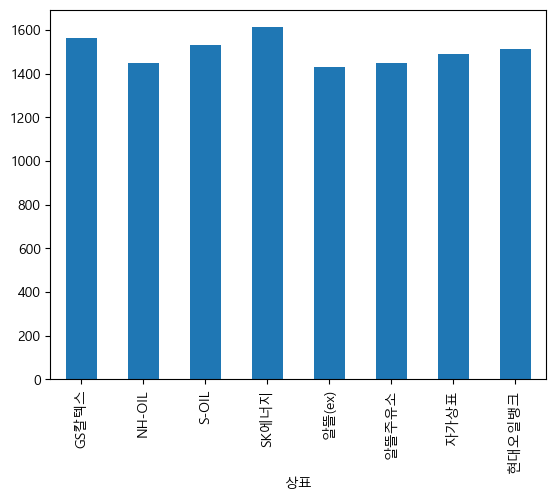

In [53]:
# 상표별 평균 휘발유 가격을 시각화하세요.
df.groupby('상표')['휘발유'].mean().plot(kind='bar')

In [54]:
# 상표와 셀프여부별 평균 휘발유 가격을 계산하세요.
df.groupby(['상표', '셀프여부'])['휘발유'].mean()

상표      셀프여부
GS칼텍스   셀프      1481.410074
        일반      1610.060123
NH-OIL  일반      1449.088889
S-OIL   셀프      1481.437428
        일반      1579.451162
SK에너지   셀프      1504.853863
        일반      1690.377765
알뜰(ex)  셀프      1431.347945
알뜰주유소   셀프      1434.726027
        일반      1455.372511
자가상표    셀프      1494.409449
        일반      1491.740351
현대오일뱅크  셀프      1483.546767
        일반      1534.254225
Name: 휘발유, dtype: float64

<Axes: xlabel='상표,셀프여부'>

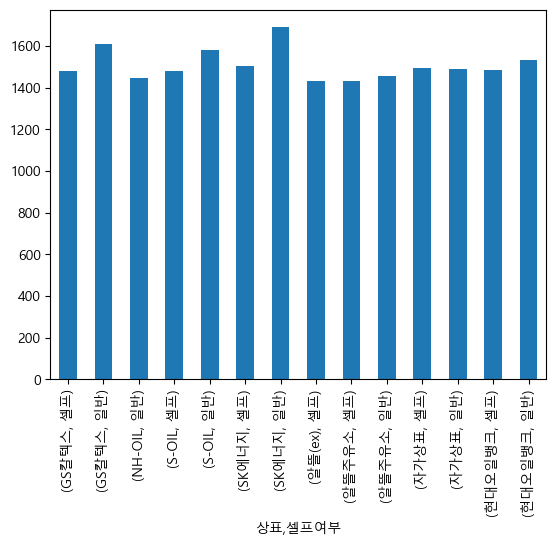

In [56]:
# 상표와 셀프여부별 평균 휘발유 가격을 시각화하세요.
df.groupby(['상표', '셀프여부'])['휘발유'].mean().plot(kind = 'bar')

<Axes: xlabel='셀프여부', ylabel='휘발유'>

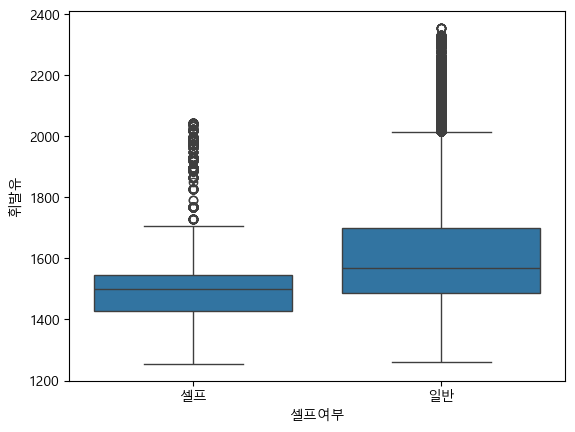

In [66]:
# 셀프여부에 따라 휘발유 가격을 boxplot으로 시각화해보세요.
# 휘발유가 0인 데이터는 제외하고 시각화합니다.
sns.boxplot(df.loc[df['휘발유']!=0], x='셀프여부', y='휘발유')

<Axes: xlabel='상표', ylabel='휘발유'>

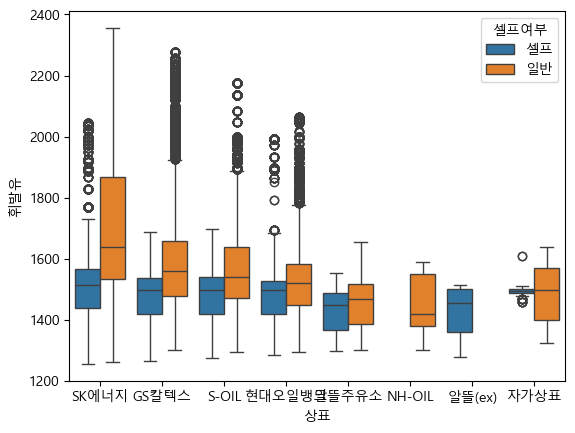

In [67]:
# 휘발유 가격과 일반 주유소의 가격을 boxplot을 이용하여 시각화해보세요.
# 휘발유가 0인 데이터는 제외하고 시각화합니다.
sns.boxplot(df.loc[df['휘발유']!=0], x='상표', y='휘발유', hue='셀프여부')

In [69]:
# 지역별 평균 휘발유 가격을 계산하세요
df.groupby('지역')['휘발유'].mean()

지역
서울 강남구     1713.093581
서울 강동구     1576.685264
서울 강북구     1453.517525
서울 강서구     1488.818088
서울 관악구     1518.128564
서울 광진구     1490.597054
서울 구로구     1525.410383
서울 금천구     1477.121992
서울 노원구     1531.221551
서울 도봉구     1494.171062
서울 동대문구    1506.833542
서울 동작구     1512.470911
서울 마포구     1689.755616
서울 서대문구    1528.943332
서울 서초구     1577.131304
서울 성동구     1583.659561
서울 성북구     1507.948267
서울 송파구     1518.957954
서울 양천구     1512.890261
서울 영등포구    1568.279506
서울 용산구     1882.049825
서울 은평구     1481.964026
서울 종로구     1838.554945
서울 중구      1976.948052
서울 중랑구     1469.009092
Name: 휘발유, dtype: float64

<Axes: xlabel='지역'>

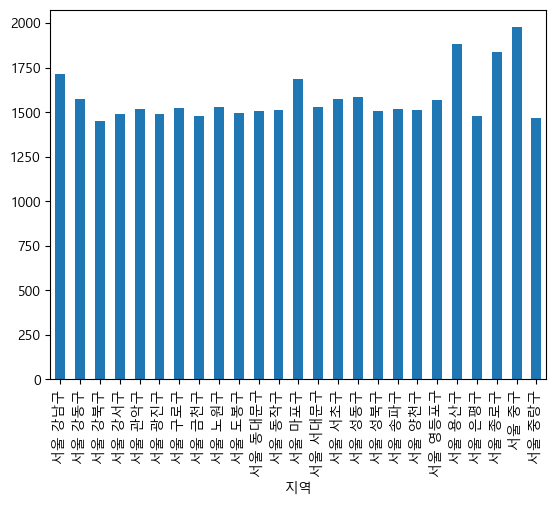

In [70]:
# 지역별 평균 휘발유 가격을 시각화하세요.
df.groupby('지역')['휘발유'].mean().plot(kind='bar')

In [71]:
# 월별 평균 휘발유 가격을 계산하세요
df.groupby('월')['휘발유'].mean()

월
1     1466.554672
2     1446.624956
3     1465.159889
4     1519.481056
5     1606.096255
6     1605.343367
7     1585.726529
8     1589.339464
9     1633.125891
10    1634.464547
11    1620.687606
12    1630.535819
Name: 휘발유, dtype: float64

<Axes: xlabel='월'>

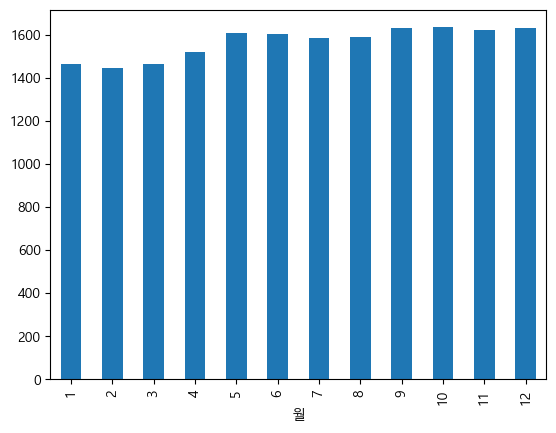

In [72]:
# 월별 평균 휘발유 가격을 시각화 하세요.
df.groupby('월')['휘발유'].mean().plot(kind='bar')

In [75]:
# pivot_table 함수를 이용하여 구와 월 컬럼을 이용하여 평균 휘발유 가격을 계산하세요
df.pivot_table(index='구', columns='월', values='휘발유')

월,1,2,3,4,5,6,7,8,9,10,11,12
구,,,,,,,,,,,,
강남구,1619.865825,1600.945536,1616.143548,1666.350000,1739.208232,1744.065833,1734.204712,1735.209040,1773.644167,1780.519355,1768.602500,1773.900082
강동구,1503.383302,1478.109244,1468.138277,1526.341667,1605.267206,1608.388309,1588.002020,1589.324597,1638.926931,1650.838710,1632.787500,1635.522177
강북구,1357.002488,1345.565934,1342.990074,1414.246154,1500.025126,1491.889744,1469.147132,1468.318408,1514.569231,1515.558313,1505.035897,1511.468983
강서구,1376.357474,1370.397959,1392.716129,1447.910749,1543.218433,1522.746425,1502.133396,1508.055028,1554.135693,1549.533207,1537.513725,1560.121673
관악구,1429.822262,1405.984127,1403.370510,1456.301230,1548.151210,1564.633333,1543.155242,1543.354839,1586.991649,1586.917339,1582.785417,1591.328629
광진구,1379.168459,1362.851190,1388.360215,1451.507407,1547.330341,1540.320370,1508.003584,1512.141818,1558.492278,1552.318868,1534.260784,1556.163188
구로구,1418.589124,1408.949675,1427.221408,1477.038052,1566.923642,1562.271212,1542.331378,1543.788856,1585.204545,1587.740061,1584.300000,1597.913978
금천구,1360.297767,1337.986264,1371.192982,1438.646154,1529.620347,1510.461538,1491.776675,1491.372208,1539.167526,1544.684864,1540.884319,1559.215881
노원구,1406.245161,1397.600000,1421.683871,1484.722222,1586.740175,1569.823661,1552.664516,1556.690323,1601.920000,1595.741935,1590.946667,1601.903226


<Axes: xlabel='월', ylabel='구'>

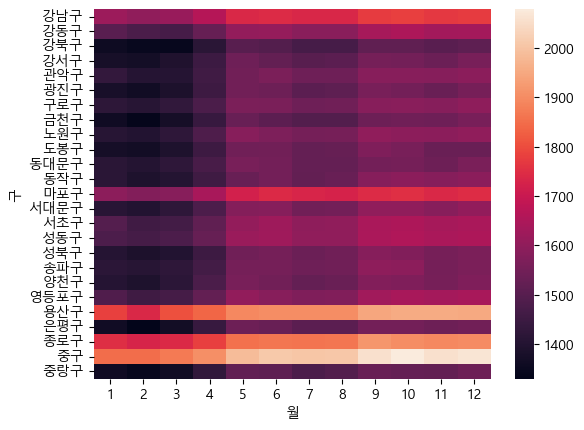

In [76]:
# pivot_table 함수를 이용하여 구와 월 컬럼을 이용하여 평균 휘발유 가격을 시각화 하세요 (heatmap 이용)
sns.heatmap(df.pivot_table(index='구', columns='월', values= '휘발유'))